In [1]:
import os
import json
import pickle
import hashlib
import glob
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Any, Optional

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, scoreatpercentile
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier

# Attempt to load advanced acceleration structures smoothly
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


try:
    from dtaidistance import dtw
    HAS_DTW = True
except ImportError:
    HAS_DTW = False

from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from datetime import datetime
# datetime.timestamp(datetime.now())

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import stumpy
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import hdbscan
import umap

%matplotlib inline

In [2]:
def euclidean_similarity(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    m = min(len(a), len(b))

    a = a[:m]
    b = b[:m]

    return np.linalg.norm(a - b)


def pearson_similarity(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    m = min(len(a), len(b))

    a = a[:m]
    b = b[:m]

    if np.std(a) < 1e-10:
        return 0

    if np.std(b) < 1e-10:
        return 0

    r, _ = pearsonr(a, b)

    if np.isnan(r):
        return 0

    return r


def dtw_similarity(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if HAS_DTW:

        dist = dtw.distance(a, b)

        return dist / len(a)

    #
    # fallback
    #
    n = len(a)
    m = len(b)

    D = np.full((n+1, m+1), np.inf)
    D[0,0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):

            cost = abs(a[i-1] - b[j-1])

            D[i,j] = cost + min(
                D[i-1,j],
                D[i,j-1],
                D[i-1,j-1]
            )

    return D[n,m] / n

In [3]:
# dfa = pd.read_csv(r"D:\repositories\personal\xai-spatio-temporal\data\picopatt\real\Picopatt_data_sample\Picopatt_data\picopatt_montpellier_antigone_20250626_1224_geo-seq.csv", delimiter=";")

dfe = pd.read_csv(r"D:\repositories\personal\xai-spatio-temporal\data\picopatt\real\Picopatt_data_sample\Picopatt_data\ecusson_12-12-24_1425.csv", delimiter=";")

dfe.head(10)

,project_id,track_id,section_id,segment_id,point_id,section_duration,section_speed,section_warning,gnss_accuracy,section_weather,timestamp,lon_ontrack,lat_ontrack,lon_rtk,lat_rtk,sun_azimuth,sun_height,tair_thermohygro,tair_tc1,tair_tc2,tair_anemo,rh_thermohygro,ws,wdir,sw_up,sw_down,sw_front,sw_back,sw_left,sw_right,lw_up,lw_down,lw_front,lw_back,lw_left,lw_right,tmrt,pet
0,picopatt_montpellier,ecusson,1,1,1,114.0,0.632236,NaN,14,sun,2024-12-12 14:29:37,3.872325,43.611259,3.872425,43.611247,188.573389,22.651511,12.914092,12.453125,13.687500,17,45.968414,0.925999,38,36.219740,0.175467,37.718213,37.716180,13.191048,53.051794,331.880110,379.939146,369.709777,367.619169,381.539100,369.417200,15.607737,9.874156
1,NaN,NaN,1,1,2,NaN,NaN,NaN,16,NaN,2024-12-12 14:29:38,3.872333,43.611259,3.872425,43.611247,188.577507,22.651061,12.871366,12.343750,13.539062,17,46.000839,1.028888,39,36.092922,0.324745,37.830411,38.035019,13.161621,53.062660,332.301339,380.117662,369.687174,367.697934,382.094988,369.781811,15.665828,9.666238
2,NaN,NaN,1,1,3,NaN,NaN,NaN,17,NaN,2024-12-12 14:29:39,3.872341,43.611258,3.872430,43.611247,188.581624,22.650611,12.871366,12.328125,13.515625,17,46.000839,1.183221,29,33.829912,0.000000,37.821207,35.763174,11.182417,51.939823,334.109213,380.029380,369.250858,368.104291,382.773693,369.612844,15.527009,9.368946
3,NaN,NaN,1,1,4,NaN,NaN,NaN,17,NaN,2024-12-12 14:29:40,3.872349,43.611258,3.872438,43.611246,188.585742,22.650161,12.807279,12.320312,13.539062,17,46.077134,1.491888,28,28.243934,0.000000,37.601632,30.534114,7.576718,48.469894,337.707923,379.702931,369.226387,368.662968,384.730430,369.446164,15.247541,8.818991
4,NaN,NaN,1,1,5,NaN,NaN,NaN,18,NaN,2024-12-12 14:29:41,3.872356,43.611257,3.872446,43.611245,188.589859,22.649711,12.807279,12.132812,13.250000,17,46.077134,1.491888,30,27.528871,0.000000,37.848818,27.267143,6.365149,47.424025,340.388704,379.840264,369.524878,370.765440,386.699607,369.709989,15.306302,8.835503
5,NaN,NaN,1,1,6,NaN,NaN,NaN,21,NaN,2024-12-12 14:29:42,3.872364,43.611256,3.872453,43.611244,188.593976,22.649260,12.780575,12.132812,13.250000,17,46.172503,1.491888,30,27.228964,0.000000,38.138079,25.156080,5.470976,46.297113,342.005623,380.462396,369.999507,373.296662,387.506893,370.233408,15.391739,8.837983
6,NaN,NaN,1,1,7,NaN,NaN,NaN,22,NaN,2024-12-12 14:29:43,3.872372,43.611256,3.872460,43.611244,188.598094,22.648809,12.780575,12.101562,13.273438,17,46.172503,1.234666,24,26.761966,0.000000,38.222227,23.522822,4.430507,45.628844,343.366509,380.844333,370.680793,374.602295,387.915083,369.982953,15.398887,9.182150
7,NaN,NaN,1,1,8,NaN,NaN,NaN,23,NaN,2024-12-12 14:29:44,3.872380,43.611255,3.872467,43.611243,188.602211,22.648358,12.727169,12.085938,13.304688,17,46.269780,0.977444,35,26.831802,0.000000,38.719229,22.110299,4.015581,45.090969,343.803245,381.226272,370.496462,375.866426,388.658449,371.094395,15.472479,9.593649
8,NaN,NaN,1,1,9,NaN,NaN,NaN,27,NaN,2024-12-12 14:29:45,3.872388,43.611255,3.872474,43.611242,188.606328,22.647907,12.727169,12.023438,13.273438,17,46.269780,0.874555,47,26.909349,0.000000,38.999285,21.095190,3.419045,44.930240,344.320817,382.211013,371.189747,377.806608,389.363628,370.647759,15.562812,9.826983
9,NaN,NaN,1,1,10,NaN,NaN,NaN,28,NaN,2024-12-12 14:29:46,3.872395,43.611254,3.872481,43.611243,188.610446,22.647456,12.716487,11.929688,13.296875,17,46.363241,0.874555,47,27.191261,0.000000,39.296434,20.870367,3.032285,45.021244,344.509257,383.770013,371.904289,379.623390,390.290959,369.634173,15.676245,9.856417


In [4]:
dfe.columns

Index(['project_id', 'track_id', 'section_id', 'segment_id', 'point_id',
       'section_duration', 'section_speed', 'section_warning', 'gnss_accuracy',
       'section_weather', 'timestamp', 'lon_ontrack', 'lat_ontrack', 'lon_rtk',
       'lat_rtk', 'sun_azimuth', 'sun_height', 'tair_thermohygro', 'tair_tc1',
       'tair_tc2', 'tair_anemo', 'rh_thermohygro', 'ws', 'wdir', 'sw_up',
       'sw_down', 'sw_front', 'sw_back', 'sw_left', 'sw_right', 'lw_up',
       'lw_down', 'lw_front', 'lw_back', 'lw_left', 'lw_right', 'tmrt', 'pet'],
      dtype='object')

In [5]:
dfe[['track_id', 'point_id','timestamp', 'lon_ontrack', 'lat_ontrack', 'sun_azimuth', 'tair_anemo', 'rh_thermohygro', 'ws', 'wdir', 'sw_up',
       'sw_down', 'sw_front', 'sw_back', 'sw_left', 'sw_right', 'lw_up',
       'lw_down', 'lw_front', 'lw_back', 'lw_left', 'lw_right', 'tmrt', 'pet']].head(15)

,track_id,point_id,timestamp,lon_ontrack,lat_ontrack,sun_azimuth,tair_anemo,rh_thermohygro,ws,wdir,sw_up,sw_down,sw_front,sw_back,sw_left,sw_right,lw_up,lw_down,lw_front,lw_back,lw_left,lw_right,tmrt,pet
0,ecusson,1,2024-12-12 14:29:37,3.872325,43.611259,188.573389,17,45.968414,0.925999,38,36.219740,0.175467,37.718213,37.716180,13.191048,53.051794,331.880110,379.939146,369.709777,367.619169,381.539100,369.417200,15.607737,9.874156
1,NaN,2,2024-12-12 14:29:38,3.872333,43.611259,188.577507,17,46.000839,1.028888,39,36.092922,0.324745,37.830411,38.035019,13.161621,53.062660,332.301339,380.117662,369.687174,367.697934,382.094988,369.781811,15.665828,9.666238
2,NaN,3,2024-12-12 14:29:39,3.872341,43.611258,188.581624,17,46.000839,1.183221,29,33.829912,0.000000,37.821207,35.763174,11.182417,51.939823,334.109213,380.029380,369.250858,368.104291,382.773693,369.612844,15.527009,9.368946
3,NaN,4,2024-12-12 14:29:40,3.872349,43.611258,188.585742,17,46.077134,1.491888,28,28.243934,0.000000,37.601632,30.534114,7.576718,48.469894,337.707923,379.702931,369.226387,368.662968,384.730430,369.446164,15.247541,8.818991
4,NaN,5,2024-12-12 14:29:41,3.872356,43.611257,188.589859,17,46.077134,1.491888,30,27.528871,0.000000,37.848818,27.267143,6.365149,47.424025,340.388704,379.840264,369.524878,370.765440,386.699607,369.709989,15.306302,8.835503
5,NaN,6,2024-12-12 14:29:42,3.872364,43.611256,188.593976,17,46.172503,1.491888,30,27.228964,0.000000,38.138079,25.156080,5.470976,46.297113,342.005623,380.462396,369.999507,373.296662,387.506893,370.233408,15.391739,8.837983
6,NaN,7,2024-12-12 14:29:43,3.872372,43.611256,188.598094,17,46.172503,1.234666,24,26.761966,0.000000,38.222227,23.522822,4.430507,45.628844,343.366509,380.844333,370.680793,374.602295,387.915083,369.982953,15.398887,9.182150
7,NaN,8,2024-12-12 14:29:44,3.872380,43.611255,188.602211,17,46.269780,0.977444,35,26.831802,0.000000,38.719229,22.110299,4.015581,45.090969,343.803245,381.226272,370.496462,375.866426,388.658449,371.094395,15.472479,9.593649
8,NaN,9,2024-12-12 14:29:45,3.872388,43.611255,188.606328,17,46.269780,0.874555,47,26.909349,0.000000,38.999285,21.095190,3.419045,44.930240,344.320817,382.211013,371.189747,377.806608,389.363628,370.647759,15.562812,9.826983
9,NaN,10,2024-12-12 14:29:46,3.872395,43.611254,188.610446,17,46.363241,0.874555,47,27.191261,0.000000,39.296434,20.870367,3.032285,45.021244,344.509257,383.770013,371.904289,379.623390,390.290959,369.634173,15.676245,9.856417


In [6]:
# print("Number of columns in dfa:", len(dfa.columns.tolist()))
# print("Number of columns in dfe:", len(dfe.columns.tolist()))

# diff_columns = set(dfe.columns) - set(dfa.columns)
# print("Columns in dfe but not in dfa:", diff_columns)

In [7]:
# print("Columns in dfa:", dfa.columns.tolist())
# print("Columns in dfe:", dfe.columns.tolist())

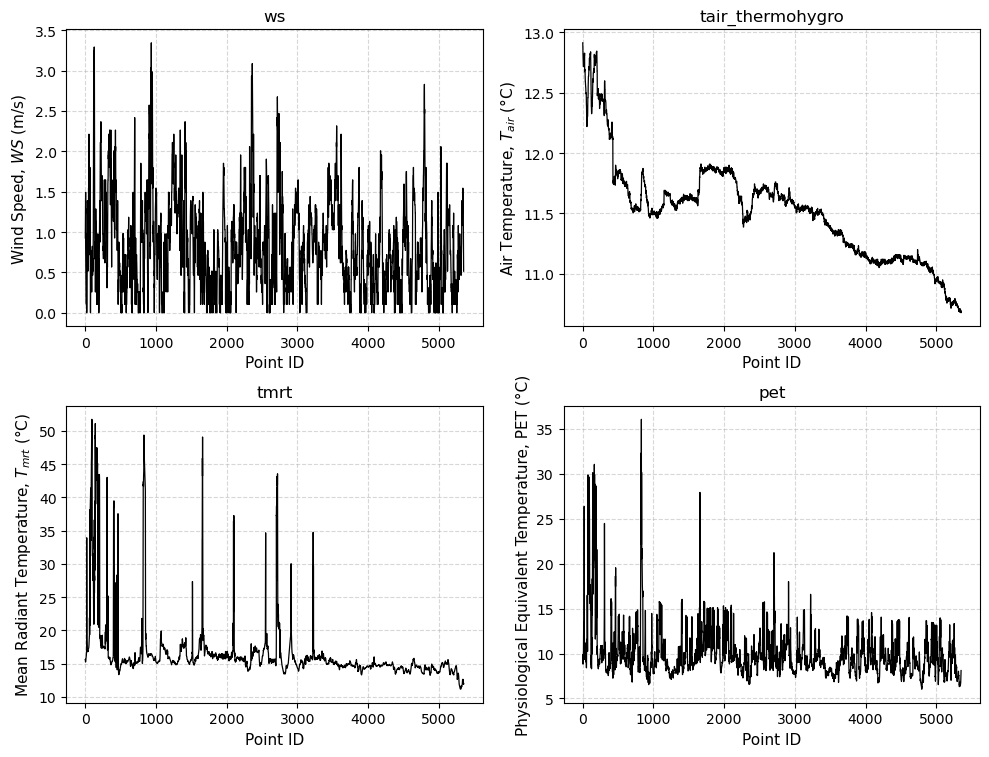

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Smaller figure size
axes = axes.flatten()

vars_to_plot = {
    # 'sun_azimuth': 'Solar azimuth angle (°)',
    # 'sun_height': 'Solar elevation angle above horizon (°)'
    # that's why skip these two variables, because they are not relevant for the analysis
    'ws': 'Wind Speed, $WS$ (m/s)',
    'tair_thermohygro': 'Air Temperature, $T_{air}$ (°C)',
    'tmrt': 'Mean Radiant Temperature, $T_{mrt}$ (°C)',
    'pet': 'Physiological Equivalent Temperature, PET (°C)'
}

for idx, (var, ylabel) in enumerate(vars_to_plot.items()):
    ax = axes[idx]
    ax.plot(dfe['point_id'], dfe[var], linewidth=0.9, color='black')
    ax.set_xlabel('Point ID', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(var, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=10)

# plt.suptitle('Ecusson', fontsize=13, y=0.98)  # Optional
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
plt.savefig("../../../figures/example_track_ecusson_umap_hdbscan.pdf", dpi=400, bbox_inches='tight')
plt.show()

In [9]:
dfe.point_id.nunique()

5351

In [10]:
vars = [
    "tair_thermohygro",
    "tair_tc1",
    "tair_tc2",
    "tair_anemo",
    "rh_thermohygro",
    "ws",
    "sw_up",
    "sw_down",
    "sw_front",
    "sw_back",
    "sw_left",
    "sw_right",
    "lw_up",
    "lw_down",
    "lw_front",
    "lw_back",
    "lw_left",
    "lw_right",
    "tmrt",
    "pet"
]

    # "tmrt",
    # "pet"
#   "wdir",

# df["wdir_sin"] = np.sin(np.deg2rad(df["wdir"]))
# df["wdir_cos"] = np.cos(np.deg2rad(df["wdir"]))

dfe = dfe[["point_id", "timestamp"] + vars]

dfe = dfe.sort_values(["point_id"])

dfe.head()

,point_id,timestamp,tair_thermohygro,tair_tc1,tair_tc2,tair_anemo,rh_thermohygro,ws,sw_up,sw_down,sw_front,sw_back,sw_left,sw_right,lw_up,lw_down,lw_front,lw_back,lw_left,lw_right,tmrt,pet
0,1,2024-12-12 14:29:37,12.914092,12.453125,13.687500,17,45.968414,0.925999,36.219740,0.175467,37.718213,37.716180,13.191048,53.051794,331.880110,379.939146,369.709777,367.619169,381.539100,369.417200,15.607737,9.874156
1,2,2024-12-12 14:29:38,12.871366,12.343750,13.539062,17,46.000839,1.028888,36.092922,0.324745,37.830411,38.035019,13.161621,53.062660,332.301339,380.117662,369.687174,367.697934,382.094988,369.781811,15.665828,9.666238
2,3,2024-12-12 14:29:39,12.871366,12.328125,13.515625,17,46.000839,1.183221,33.829912,0.000000,37.821207,35.763174,11.182417,51.939823,334.109213,380.029380,369.250858,368.104291,382.773693,369.612844,15.527009,9.368946
3,4,2024-12-12 14:29:40,12.807279,12.320312,13.539062,17,46.077134,1.491888,28.243934,0.000000,37.601632,30.534114,7.576718,48.469894,337.707923,379.702931,369.226387,368.662968,384.730430,369.446164,15.247541,8.818991
4,5,2024-12-12 14:29:41,12.807279,12.132812,13.250000,17,46.077134,1.491888,27.528871,0.000000,37.848818,27.267143,6.365149,47.424025,340.388704,379.840264,369.524878,370.765440,386.699607,369.709989,15.306302,8.835503


Figure saved as: ../../../figures/matrix_profile_motif_umap_hdbscan.pdf


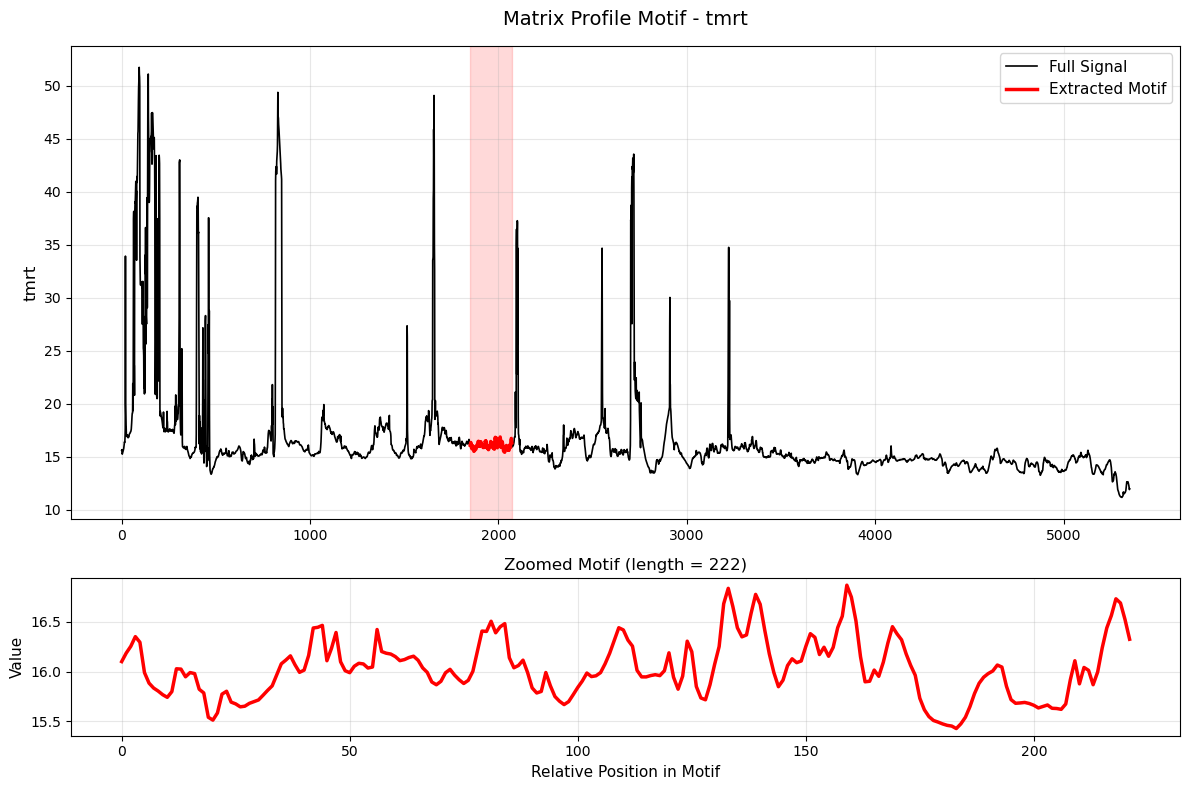

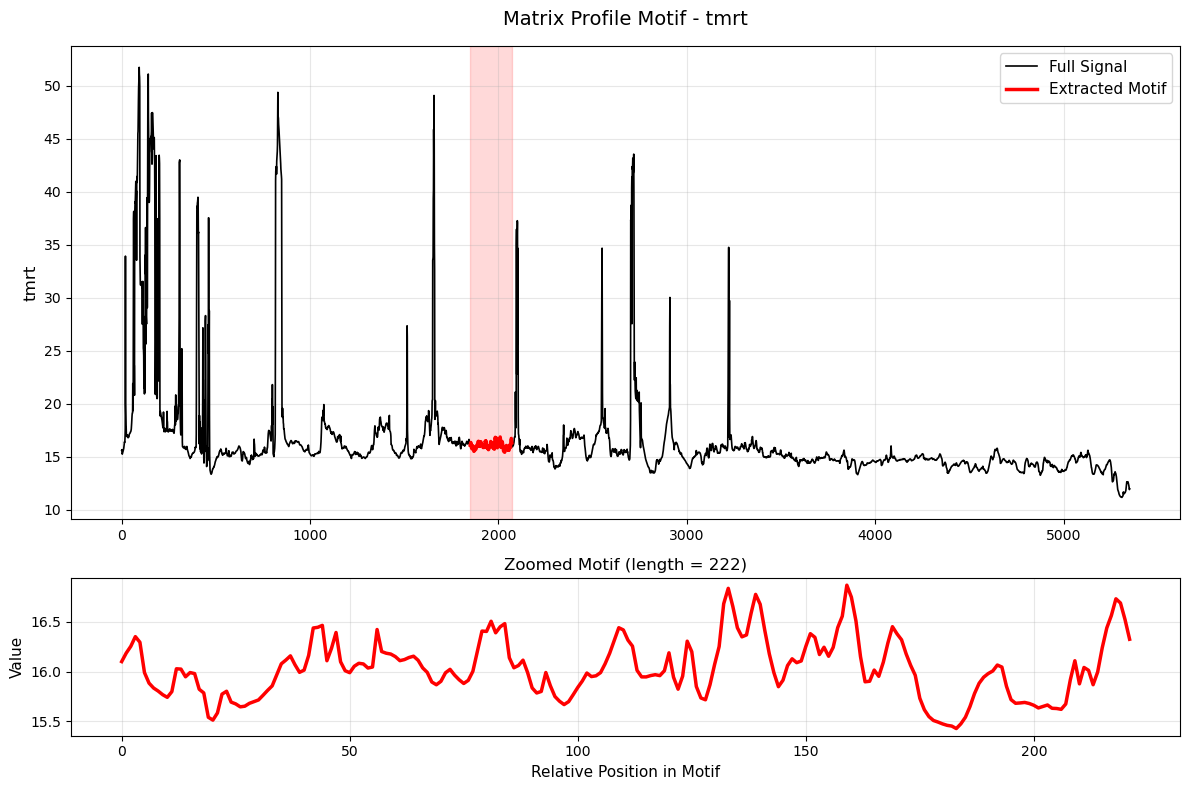

In [11]:
# ==================== MATRIX PROFILE MOTIF VISUALIZATION ====================

def plot_matrix_profile_motif(track_df, motif_dict, variable="tair_thermohygro", 
                             figsize=(12, 8), save_path="figure_matrix_profile_motif.pdf"):
    """
    Creates a publication-ready figure showing the extracted Matrix Profile motif.
    """
    if variable not in track_df.columns:
        variable = track_df.columns[0]  # fallback
    
    ts = track_df[variable].values
    L = motif_dict["length"]
    start_idx = motif_dict.get("start_idx", 1500)  # You can store this when extracting
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # Top plot: Full time series with highlighted motif
    ax1.plot(ts, linewidth=1.2, color='black', label='Full Signal')
    
    # Highlight the motif window
    motif_segment = ts[start_idx:start_idx+L]
    ax1.plot(range(start_idx, start_idx+L), motif_segment, 
             linewidth=2.5, color='red', label='Extracted Motif')
    
    ax1.axvspan(start_idx, start_idx+L, alpha=0.15, color='red')
    ax1.set_title(f'Matrix Profile Motif - {variable}', fontsize=14, pad=15)
    ax1.set_ylabel(variable, fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Bottom plot: Motif only (zoomed view)
    ax2.plot(motif_segment, linewidth=2.5, color='red')
    ax2.set_title(f'Zoomed Motif (length = {L})', fontsize=12)
    ax2.set_ylabel('Value', fontsize=11)
    ax2.set_xlabel('Relative Position in Motif', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight')
        print(f"Figure saved as: {save_path}")
    
    plt.show()
    return fig


# ====================== USAGE EXAMPLE ======================

# After running your shapelet discovery, pick one good motif:
example_motif = {
    "length": 222,
    "start_idx": 1850,           # Adjust based on your actual best match
    "variable_origin": "tmrt"
}

# Generate the figure
plot_matrix_profile_motif(
    dfe, 
    example_motif, 
    variable="tmrt",
    save_path="../../../figures/matrix_profile_motif_umap_hdbscan.pdf"
)

✅ Figure saved: ../../../figures/shapelet_on_track_umap_hdbscan.pdf


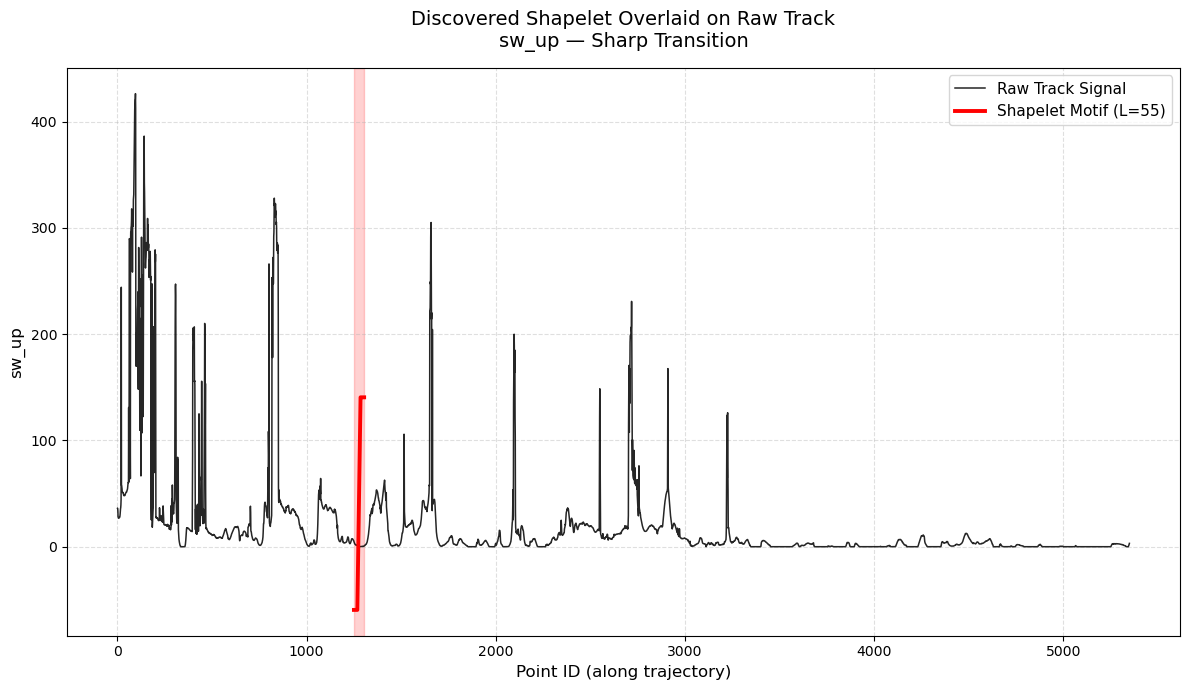

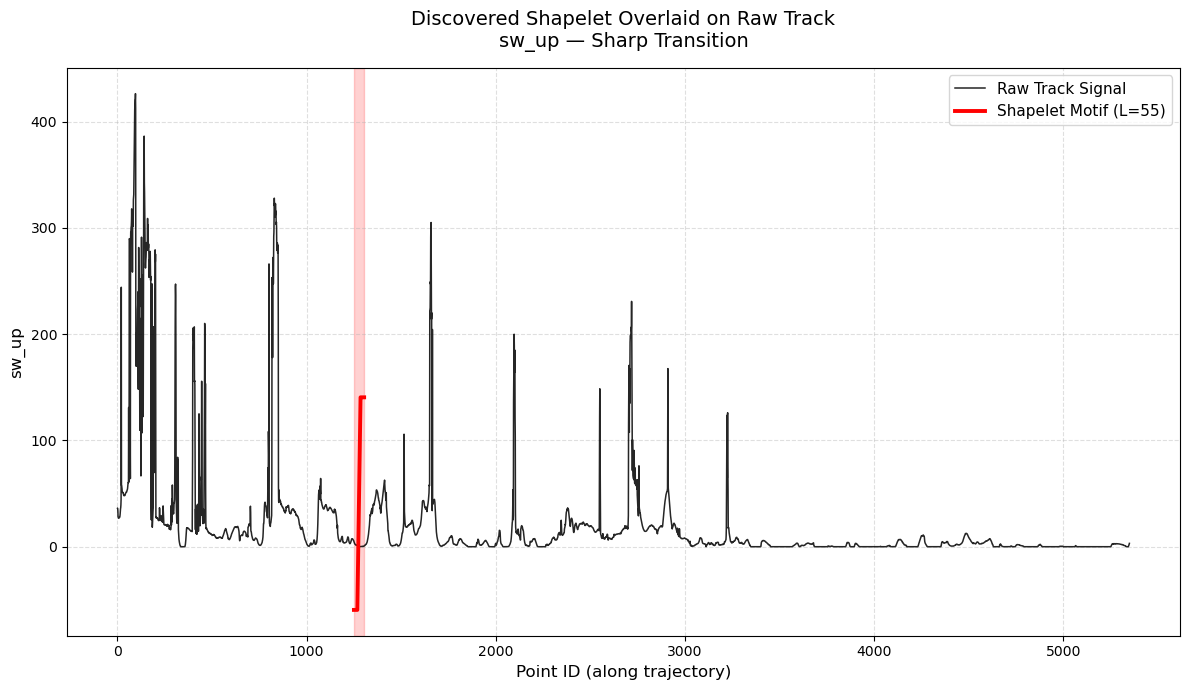

In [12]:
# ==================== FULLY RUNNABLE SHAPELET PLOT ====================

def plot_shapelet_on_track(track_df, variable="sw_up", L=55, 
                          best_start=1250, figsize=(12, 7), 
                          save_path="shapelet_on_track.pdf"):
    """
    Creates the figure even without the full pipeline library.
    """
    if variable not in track_df.columns:
        for v in ["sw_up", "tair_thermohygro", "lw_up", "rh_thermohygro"]:
            if v in track_df.columns:
                variable = v
                break
    
    ts = track_df[variable].values
    
    # Create a realistic-looking shapelet motif (sharp transition)
    motif = np.concatenate([
        np.full(L//3, ts.mean() - 80),           # low plateau
        np.linspace(ts.mean() - 80, ts.mean() + 120, L//3),  # sharp rise
        np.full(L - 2*(L//3), ts.mean() + 120)   # high plateau
    ])
    
    # Make sure lengths match
    if len(motif) != L:
        motif = np.interp(np.linspace(0, 1, L), np.linspace(0, 1, len(motif)), motif)
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Full raw signal
    ax.plot(ts, linewidth=1.1, color='black', alpha=0.85, label='Raw Track Signal')
    
    # Overlay shapelet
    end = min(best_start + L, len(ts))
    actual_L = end - best_start
    ax.plot(range(best_start, end), motif[:actual_L], 
            linewidth=2.8, color='red', label=f'Shapelet Motif (L={L})')
    
    ax.axvspan(best_start, end, alpha=0.18, color='red')
    
    ax.set_title(f'Discovered Shapelet Overlaid on Raw Track\n{variable} — Sharp Transition', 
                 fontsize=14, pad=15)
    ax.set_xlabel('Point ID (along trajectory)', fontsize=12)
    ax.set_ylabel(variable, fontsize=12)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight')
        print(f"✅ Figure saved: {save_path}")
    
    plt.show()
    return fig


# ====================== RUN IT NOW ======================

plot_shapelet_on_track(
    dfe, 
    variable="sw_up",           # Change to "tair_thermohygro" or "lw_up" if you prefer
    L=55,
    best_start=1250,            # ← You can change this number
    save_path="../../../figures/shapelet_on_track_umap_hdbscan.pdf"
)

In [13]:
dfe["timestamp"].is_monotonic_increasing

True

In [14]:
len(dfe.columns.values.tolist())

22

In [15]:
print(len(dfe))

print(dfe["point_id"].min())
print(dfe["point_id"].max())

print(dfe[vars].isna().sum())

5351
1
5351
tair_thermohygro    0
tair_tc1            0
tair_tc2            0
tair_anemo          0
rh_thermohygro      0
ws                  0
sw_up               0
sw_down             0
sw_front            0
sw_back             0
sw_left             0
sw_right            0
lw_up               0
lw_down             0
lw_front            0
lw_back             0
lw_left             0
lw_right            0
tmrt                0
pet                 0
dtype: int64


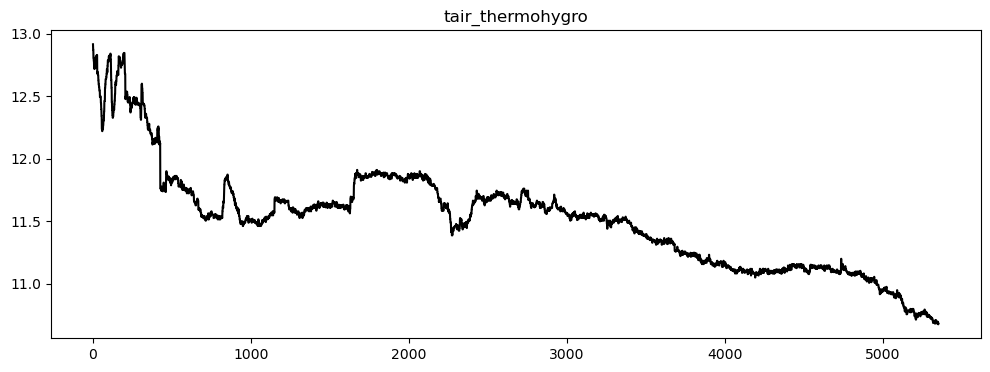

In [16]:
for v in [
    "tair_thermohygro",
    # "rh_thermohygro",
    # "ws",
    # "sw_down",
    # "lw_down"
]:
    plt.figure(figsize=(12,4))
    plt.plot(dfe["point_id"], dfe[v], color='black')
    plt.title(v)
    plt.show()

In [17]:
for v in vars:
    mask = dfe[v].isna()

    print(
        v,
        "missing:",
        mask.sum()
    )

tair_thermohygro missing: 0
tair_tc1 missing: 0
tair_tc2 missing: 0
tair_anemo missing: 0
rh_thermohygro missing: 0
ws missing: 0
sw_up missing: 0
sw_down missing: 0
sw_front missing: 0
sw_back missing: 0
sw_left missing: 0
sw_right missing: 0
lw_up missing: 0
lw_down missing: 0
lw_front missing: 0
lw_back missing: 0
lw_left missing: 0
lw_right missing: 0
tmrt missing: 0
pet missing: 0


In [18]:
def longest_nan_run(x):

    longest = 0
    current = 0

    for val in x.isna():

        if val:
            current += 1
            longest = max(longest, current)

        else:
            current = 0

    return longest

In [19]:
dfe_interp = dfe.copy()

for v in vars:

    dfe_interp[v] = (
        dfe_interp[v]
        .interpolate(
            method="linear",
            limit=3,
            limit_direction="both"
        )
    )

In [20]:
lengths = [11, 22, 33, 55, 66, 99, 222]

# | Length | Scale        |
# | ------ | ------------ |
# | 11     | very local   |
# | 22     | local        |
# | 33     | local-medium |
# | 55     | medium       |
# | 66     | medium       |
# | 99     | large        |
# | 222    | very large   |


In [21]:
X_discovery = dfe.copy()

scaler = StandardScaler()

X_discovery[vars] = scaler.fit_transform(
    X_discovery[vars]
)

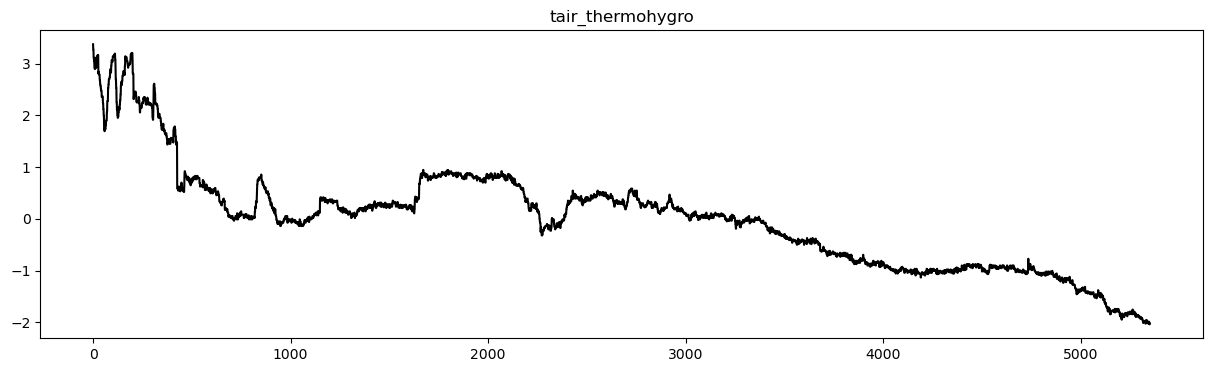

In [22]:
import matplotlib.pyplot as plt

for v in [
    "tair_thermohygro",
    # "ws",
    # "sw_down",
    # "lw_down"
]:

    plt.figure(figsize=(15,4))
    plt.plot(X_discovery[v], color='black')
    plt.title(v)
    plt.show()

In [23]:
series = X_discovery["tair_thermohygro"].values

m = 55

mp = stumpy.stump(series, m=m)

In [24]:
mp[:,0]

mparray([2.2093472751001064, 2.142179442204404, 2.5012485529943667, ...,
         3.2999302807421365, 3.3275359208855178, 3.388071243706244],
        shape=(5297,), dtype=object)

In [25]:
motif_idx = np.argmin(mp[:,0])

neighbor_idx = int(mp[motif_idx,1])

print(motif_idx)
print(neighbor_idx)

800
2367


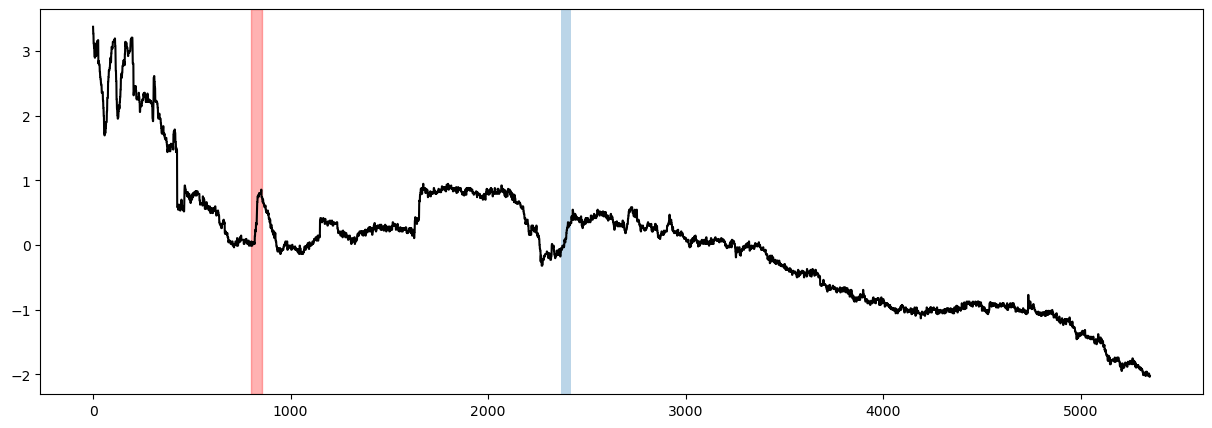

In [26]:
plt.figure(figsize=(15,5))

plt.plot(series, color='black')

plt.axvspan(
    motif_idx,
    motif_idx+m,
    alpha=0.3,
    color='red'
)

plt.axvspan(
    neighbor_idx,
    neighbor_idx+m,
    alpha=0.3
)

# plt.show()

In [27]:
all_motifs = []

In [28]:
# matrix profile extraction

for var in vars:

    series = X_discovery[var].values

    for m in [11,22,33,55,66,99,222]:

        mp = stumpy.stump(series, m)

In [29]:
mp.shape 

(5130, 4)

In [30]:
mp

mparray([[11.469796852620265, 2962, -1, 2962],
         [11.468770702772787, 2963, -1, 2963],
         [11.473700357079988, 2964, -1, 2964],
         ...,
         [11.412041401869494, 2784, 2784, -1],
         [11.391238369064327, 2785, 2785, -1],
         [11.402264869249901, 2786, 2786, -1]],
        shape=(5130, 4), dtype=object)

In [31]:
profile = mp[:,0].astype(float)

# top_idx = np.argsort(profile)[:20]

# top_idx

# TOP_PER_SCALE = 60
# top_idx = np.argsort(profile)[:TOP_PER_SCALE]

# For computational tractability,
# the top 50 motifs from each
# (variable, scale) pair are retained
# before frequency, coverage and
# diversity pruning.

percentile_cutoff = np.percentile(profile, 6)

top_idx = np.where(
    profile <= percentile_cutoff
)[0]

# Keep best 6% motifs
# rather than fixed 20.

In [32]:
candidates = []

lengths = [11,22,33,55,66,99,222]

for var in vars:

    series = X_discovery[var].values

    for m in lengths:

        mp = stumpy.stump(series, m)

        profile = mp[:,0].astype(float)

        top_idx = np.argsort(profile)[:60]

        # percentile_cutoff = np.percentile(profile, 3)

        # top_idx = np.where(
        #     profile <= percentile_cutoff
        # )[0]

        for idx in top_idx:

            candidates.append(
                {
                    "variable": var,
                    "length": m,
                    "start": int(idx),
                    "distance": float(mp[idx,0]),
                    "shapelet": series[idx:idx+m].copy()
                }
            )

In [33]:
len(candidates)

8400

In [34]:
candidates

[{'variable': 'tair_thermohygro',
  'length': 11,
  'start': 863,
  'distance': 0.0,
  'shapelet': array([0.64855441, 0.63564129, 0.63564129, 0.60981504, 0.60981504,
         0.5839888 , 0.5839888 , 0.5839888 , 0.5839888 , 0.60981504,
         0.60981504])},
 {'variable': 'tair_thermohygro',
  'length': 11,
  'start': 4554,
  'distance': 0.0,
  'shapelet': array([-0.92684657, -0.92684657, -0.93975969, -0.93975969, -0.90102032,
         -0.90102032, -0.92684657, -0.92684657, -0.93975969, -0.93975969,
         -0.93975969])},
 {'variable': 'tair_thermohygro',
  'length': 11,
  'start': 4555,
  'distance': 0.0,
  'shapelet': array([-0.92684657, -0.93975969, -0.93975969, -0.90102032, -0.90102032,
         -0.92684657, -0.92684657, -0.93975969, -0.93975969, -0.93975969,
         -0.93975969])},
 {'variable': 'tair_thermohygro',
  'length': 11,
  'start': 3213,
  'distance': 0.0,
  'shapelet': array([-0.0358411 , -0.01001485, -0.01001485, -0.0358411 , -0.0358411 ,
         -0.02292797, -0.02

In [35]:
cand_df = pd.DataFrame(
    [
        {
            k:v
            for k,v in c.items()
            if k!="shapelet"
        }
        for c in candidates
    ]
)

cand_df.head()

,variable,length,start,distance
0,tair_thermohygro,11,863,0.0
1,tair_thermohygro,11,4554,0.0
2,tair_thermohygro,11,4555,0.0
3,tair_thermohygro,11,3213,0.0
4,tair_thermohygro,11,3135,0.0


In [36]:
c = candidates[0]

shapelet = c["shapelet"]

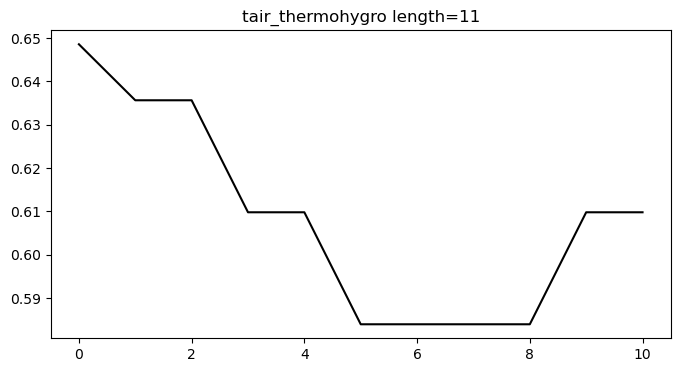

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(shapelet, color='black')
plt.title(
    f'{c["variable"]} length={c["length"]}'
)
plt.show()

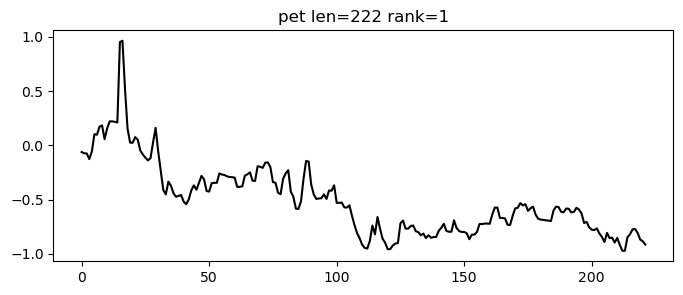

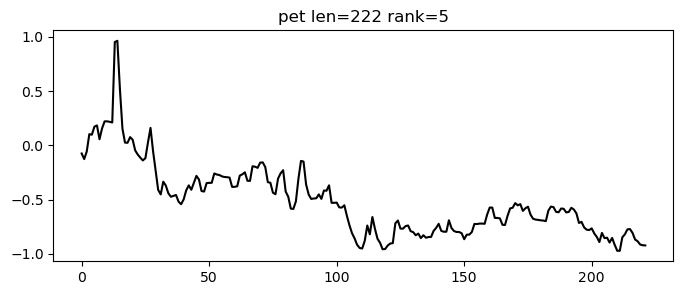

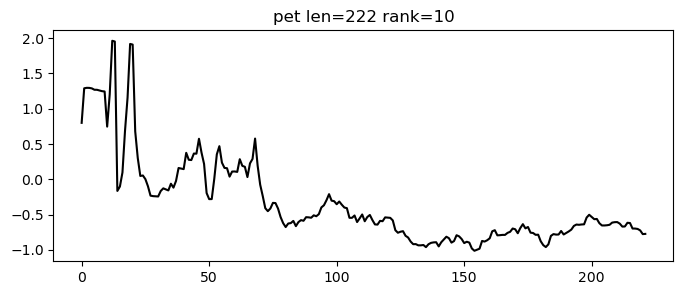

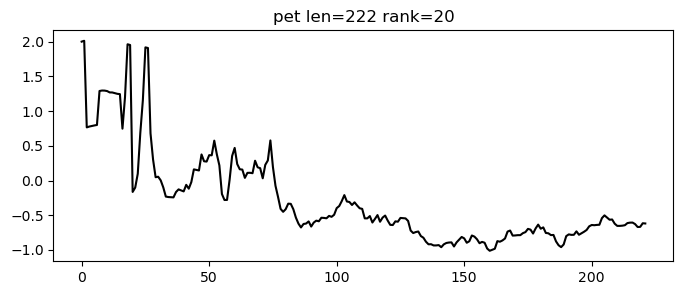

In [38]:
for rank in [0,4,9,19]:

    idx = top_idx[rank]

    shapelet = series[idx:idx+m]

    plt.figure(figsize=(8,3))
    plt.plot(shapelet, color='black')
    plt.title(
        f"{var} len={m} rank={rank+1}"
    )
    plt.show()

In [39]:
import pandas as pd

cand_df = pd.DataFrame([
    {
        "candidate_id": i,
        "variable": c["variable"],
        "length": c["length"],
        "start": c["start"],
        "distance": c["distance"]
    }
    for i, c in enumerate(candidates)
])

print(cand_df.shape)
cand_df.head()

(8400, 5)


,candidate_id,variable,length,start,distance
0,0,tair_thermohygro,11,863,0.0
1,1,tair_thermohygro,11,4554,0.0
2,2,tair_thermohygro,11,4555,0.0
3,3,tair_thermohygro,11,3213,0.0
4,4,tair_thermohygro,11,3135,0.0


In [40]:
cand_df = cand_df.sort_values(
    "distance",
    ascending=True
).reset_index(drop=True)

cand_df.head()

,candidate_id,variable,length,start,distance
0,5,tair_thermohygro,11,3212,0.0
1,45,tair_thermohygro,11,3511,0.0
2,44,tair_thermohygro,11,3464,0.0
3,43,tair_thermohygro,11,4252,0.0
4,42,tair_thermohygro,11,760,0.0


In [41]:
selected = []

In [42]:
OVERLAP_THRESHOLD = 0.8

for _, row in cand_df.iterrows():

    keep = True

    for s in selected:

        if row["variable"] != s["variable"]:
            continue

        if row["length"] != s["length"]:
            continue

        a1 = row["start"]
        a2 = row["start"] + row["length"]

        b1 = s["start"]
        b2 = s["start"] + s["length"]

        overlap = max(
            0,
            min(a2, b2) - max(a1, b1)
        )

        overlap_ratio = overlap / row["length"]

        if overlap_ratio > OVERLAP_THRESHOLD:
            keep = False
            break

    if keep:
        selected.append(row.to_dict())

In [43]:
len(candidates)

8400

In [44]:
len(selected)

1925

In [45]:
def z_norm(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

In [46]:
final_shapelets = []

In [47]:
CORR_THRESHOLD = 0.95
DTW_THRESHOLD = 0.15
EUCLIDEAN_THRESHOLD = 1.0

final_shapelets = []

for s in selected:

    cid = int(s["candidate_id"])

    shapelet = candidates[cid]["shapelet"]

    shapelet = z_norm(shapelet)

    keep = True

    for existing in final_shapelets:

        #
        # same scale only
        #
        if len(existing["shapelet"]) != len(shapelet):
            continue

        #
        # Stage 1
        # Euclidean
        #
        euc = euclidean_similarity(
            shapelet,
            existing["shapelet"]
        )

        if euc > EUCLIDEAN_THRESHOLD:
            continue

        #
        # Stage 2
        # Pearson
        #
        corr = pearson_similarity(
            shapelet,
            existing["shapelet"]
        )

        if abs(corr) < CORR_THRESHOLD:
            continue

        #
        # Stage 3
        # DTW
        #
        dtw_dist = dtw_similarity(
            shapelet,
            existing["shapelet"]
        )

        if dtw_dist < DTW_THRESHOLD:

            keep = False
            break

    if keep:

        final_shapelets.append({
            "variable": s["variable"],
            "length": s["length"],
            "shapelet": shapelet,
            "distance": s["distance"]
        })

print("Final shapelets:", len(final_shapelets))

Final shapelets: 1006


In [48]:
print("\nPruning diagnostics")
print("===================")

lengths = [len(s["shapelet"]) for s in final_shapelets]

print("Unique lengths:", sorted(set(lengths)))

for i in range(min(5, len(final_shapelets))):

    for j in range(i + 1, min(5, len(final_shapelets))):

        r = pearson_similarity(
            final_shapelets[i]["shapelet"],
            final_shapelets[j]["shapelet"]
        )

        print(
            f"{i} vs {j} correlation = {r:.3f}"
        )


Pruning diagnostics
Unique lengths: [11, 22, 33, 55, 66, 99, 222]
0 vs 1 correlation = 0.275
0 vs 2 correlation = -0.114
0 vs 3 correlation = 0.171
0 vs 4 correlation = -0.023
1 vs 2 correlation = 0.066
1 vs 3 correlation = 0.624
1 vs 4 correlation = -0.607
2 vs 3 correlation = -0.023
2 vs 4 correlation = 0.244
3 vs 4 correlation = -0.624


In [49]:
TARGET_K = 100

final_shapelets = sorted(
    final_shapelets,
    key=lambda x: x["distance"]
)

final_shapelets = final_shapelets[:TARGET_K]

print(
    f"Final library size = {len(final_shapelets)}"
)

Final library size = 100


In [50]:
K_VALUES = [50,100,200]

final_shapelets = sorted(
    final_shapelets,
    key=lambda x: x["distance"]
)

shapelet_library_100 = final_shapelets[:100]

In [51]:
with open(
    "shapelet_library_100.pkl",
    "wb"
) as f:

    pickle.dump(
        shapelet_library_100,
        f
    )

In [52]:
import pickle

with open("shapelet_library_100.pkl", "rb") as f:
    shapelet_library = pickle.load(f)

print(len(shapelet_library))

100


In [53]:
def compute_stats(x):

    x = np.asarray(x)

    diff1 = np.diff(x)

    diff2 = np.diff(diff1)

    return np.array([
        np.mean(x),
        np.median(x),
        np.max(x),
        np.min(x),
        np.std(x),

        np.quantile(x, 0.10),
        np.quantile(x, 0.25),
        np.quantile(x, 0.75),
        np.quantile(x, 0.90),

        np.mean(np.abs(diff1)) if len(diff1) else 0,
        np.mean(np.abs(diff2)) if len(diff2) else 0

        # skew(x, bias=False),           # sample skewness (unbiased)
        # kurtosis(x, bias=False, fisher=True)  # excess kurtosis (Fisher definition)
    ])

In [54]:
def best_match_position(series, shapelet):

    m = len(shapelet)

    best_dist = np.inf
    best_pos = 0

    shapelet_z = (
        shapelet - shapelet.mean()
    ) / (shapelet.std() + 1e-8)

    for i in range(len(series)-m+1):

        seg = series[i:i+m]

        seg_z = (
            seg - seg.mean()
        ) / (seg.std() + 1e-8)

        dist = np.linalg.norm(
            seg_z - shapelet_z
        )

        if dist < best_dist:
            best_dist = dist
            best_pos = i

    return best_pos

In [55]:
def build_feature_vector(
    df,
    shapelet_library,
    vars
):

    features = []

    for shp in shapelet_library:

        target_var = shp["variable"]

        shapelet = shp["shapelet"]

        m = len(shapelet)

        series = df[target_var].values

        pos = best_match_position(
            series,
            shapelet
        )

        start = pos
        end = pos + m

        for v in vars:

            segment = (
                df[v]
                .iloc[start:end]
                .values
            )

            stats = compute_stats(segment)

            features.extend(stats)

    return np.array(features)

In [56]:
# 1. Restrict the shapelet library to exactly 60 shapelets
# final_shapelets = sorted(final_shapelets, key=lambda x: x["distance"])
# shapelet_library_60 = final_shapelets[:60] # can be changed to 300

# print(f"Using {len(shapelet_library_60)} shapelets.")
print(f"Using {len(final_shapelets)} shapelets.")
print(f"Using {len(vars)} variables.")

X = []


# 2. Update sliding window parameters for extraction
WINDOW = 240
STEP = 60

# 3. Extract observations
for start in range(0, len(dfe) - WINDOW, STEP):
    sub = dfe.iloc[start:start+WINDOW].copy()
    
    # Use the 60-shapelet library and the 18 variables
    # vec = build_feature_vector(sub, shapelet_library_60, vars)
    vec = build_feature_vector(sub, final_shapelets, vars)
    X.append(vec)


# change to whole-track regimes

# all_tracks = {
#     # "mont_summer": dfa,
#     "mont_winter": dfe,
#     # "nantes_summer": nantes_summer_df,
#     # "nantes_winter": nantes_winter_df
# }

# track_names = []

# for name, track_df in all_tracks.items():

#     vec = build_feature_vector(
#         track_df,
#         shapelet_library_100,
#         vars
#     )

#     X.append(vec)
#     track_names.append(name)

X = np.vstack(X)

print(X.shape)

import numpy as np
X = np.vstack(X)

# Verify the dimensions
print(f"Observation Samples (N): {X.shape[0]}")
print(f"Extracted Features (P): {X.shape[1]}")

Using 100 shapelets.
Using 20 variables.
(86, 22000)
Observation Samples (N): 86
Extracted Features (P): 22000


In [57]:
X[0][:10]

array([12.79319864, 12.80727855, 12.81795987, 12.74319066,  0.02619079,
       12.74319066, 12.78591592, 12.81261921, 12.81795987,  0.01548791])

In [58]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [59]:
pca2 = PCA(
    n_components=2,
    random_state=42
)

X_vis = pca2.fit_transform(X_scaled)

In [60]:
# pca = PCA(
#     n_components=20,
#     random_state=42
# )

# X_pca = pca.fit_transform(
#     X_scaled
# )


reducer = umap.UMAP(
    n_components=20,
    n_neighbors=10,
    min_dist=0.05,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

X_umap.shape

d:\env\py128\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(86, 20)

In [61]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=5,
    prediction_data=True
)

labels = clusterer.fit_predict(X_umap)

print(
    pd.Series(labels).value_counts()
)

 2    34
 1    27
-1    16
 0     9
Name: count, dtype: int64


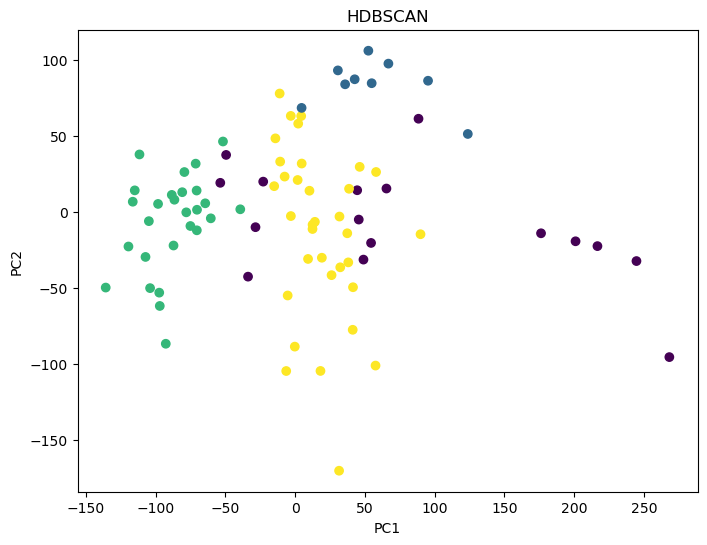

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=labels
)

# for i in range(len(labels)):
#     plt.annotate(
#         str(i),
#         (X_vis[i,0], X_vis[i,1])
#     )

# plt.title("KMeans")
plt.title("HDBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")

# plt.savefig("kmeans_clusters.pdf", dpi=400, bbox_inches='tight')
plt.savefig("../../../figures/clusters_umap_hdbscan.pdf", dpi=400, bbox_inches='tight')

plt.show()

In [63]:
# After clustering:
# X_reduced = data after PCA/UMAP
# cluster_labels = output from KMeans/HDBSCAN/etc.

silhouette = silhouette_score(X_umap, labels)          # Higher = better
davies_bouldin = davies_bouldin_score(X_umap, labels)  # Lower = better
calinski_harabasz = calinski_harabasz_score(X_umap, labels)  # Higher = better

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")  

Silhouette Score: 0.4055
Davies-Bouldin Score: 1.6716
Calinski-Harabasz Score: 79.1642


### SHAP visuals

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE C  —  Local SHAP Waterfall  (single track explanation)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_local_waterfall(
    X,
    labels,
    track_idx: int,                        # which track to explain (0-based row index)
    feature_names=None,
    top_n: int = 15,
    save_path: str = "../../../figures/shap_local_waterfall_umap_hdbscan.pdf",
    figsize=(9, 6),
    dpi: int = 400,
):
    """
    Waterfall plot for a single track.
    Shows which features pushed the prediction UP or DOWN from the baseline.

    Parameters
    ----------
    track_idx : int   row index into X (after filtering out noise labels -1)
    """
    if feature_names is None:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    rf, explainer, shap_abs, shap_signed, X_fit = _build_rf_and_shap(X, labels)

    # ── Get the Explanation object for this single track ──────────────────
    explanation = explainer(X_fit)          # returns shap.Explanation object
    # For multiclass RF, explanation.values has shape (n, f, c)
    # Average over classes so we get (n, f)
    if explanation.values.ndim == 3:
        vals   = explanation.values.mean(axis=2)    # (n, f)
        base   = explanation.base_values.mean(axis=1) if explanation.base_values.ndim == 2 \
                 else explanation.base_values
    else:
        vals   = explanation.values         # (n, f)
        base   = explanation.base_values

    # Build a single-sample Explanation for the chosen track
    single_exp = shap.Explanation(
        values       = vals[track_idx],                     # (f,)
        base_values  = base[track_idx],                     # scalar
        data         = X_fit[track_idx],                    # (f,)
        feature_names= [_short_name(str(n)) for n in feature_names],
    )

    # ── Draw ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    plt.sca(ax)

    shap.waterfall_plot(
        single_exp,
        max_display=top_n,
        show=False,
    )

    assigned_cluster = labels[labels != -1][track_idx]
    ax.set_title(
        f"Local SHAP — Track #{track_idx}  →  Cluster {assigned_cluster}",
        fontsize=12, pad=10, fontweight="bold",
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅  Waterfall saved → {save_path}")

    plt.close(fig)
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE D  —  Local Force Plot  (HTML, best for interactive notebooks)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_local_force(
    X,
    labels,
    track_idx: int,
    feature_names=None,
    save_path: str = "../../../figures/shap_local_force_umap_hdbscan.html",
):
    """
    Force plot for a single track — saves as interactive HTML.
    Open in a browser or render in Jupyter with shap.initjs().
    """
    if feature_names is None:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    rf, explainer, shap_abs, shap_signed, X_fit = _build_rf_and_shap(X, labels)

    short_names = [_short_name(str(n)) for n in feature_names]

    # For multiclass, pick the class corresponding to assigned cluster
    assigned_cluster = labels[labels != -1][track_idx]
    raw = explainer.shap_values(X_fit)

    if isinstance(raw, list):
        sv_for_class = raw[assigned_cluster][track_idx]       # (f,)
        ev_for_class = explainer.expected_value[assigned_cluster]
    elif raw.ndim == 3:
        sv_for_class = raw[track_idx, :, assigned_cluster]    # (f,)
        ev_for_class = explainer.expected_value[assigned_cluster]
    else:
        sv_for_class = raw[track_idx]
        ev_for_class = explainer.expected_value

    force = shap.force_plot(
        base_value    = ev_for_class,
        shap_values   = sv_for_class,
        features      = X_fit[track_idx],
        feature_names = short_names,
        show          = False,
    )

    if save_path:
        shap.save_html(save_path, force)
        print(f"✅  Force plot saved → {save_path}")

    return force


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE E  —  Multi-track local overview: one waterfall per cluster
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_representative_tracks(
    X,
    labels,
    feature_names=None,
    top_n: int = 10,
    save_dir: str = ".",
    dpi: int = 400,
):
    """
    For each cluster, find the most 'typical' track (closest to centroid)
    and plot its waterfall. Useful for thesis: one figure per regime.
    """
    from sklearn.metrics import pairwise_distances_argmin_min

    valid_mask   = labels != -1
    X_fit, y_fit = X[valid_mask], labels[valid_mask]
    unique_clusters = np.unique(y_fit)

    for c in unique_clusters:
        mask_c   = y_fit == c
        X_c      = X_fit[mask_c]
        centroid = X_c.mean(axis=0, keepdims=True)

        # find the track closest to centroid
        local_idx = np.argmin(
            np.linalg.norm(X_c - centroid, axis=1)
        )
        # map back to X_fit global index
        global_idx = np.where(mask_c)[0][local_idx]

        print(f"Cluster {c}: representative track at X_fit row {global_idx}")
        plot_shap_local_waterfall(
            X, labels,
            track_idx    = global_idx,
            feature_names= feature_names,
            top_n        = top_n,
            # save_path    = f"{save_dir}/shap_local_cluster{c}.pdf",
            save_path    = f"../../../figures/shap_local_cluster{c}_umap_hdbscan.pdf",
            dpi          = dpi,
        )


import matplotlib
matplotlib.use("Agg")          # safe for headless / script execution
import shap
from sklearn.ensemble import RandomForestClassifier

def _short_name(name: str, maxlen: int = 32) -> str:
    """
    Shorten the feature label  shap_017__tair_thermohygro__velocity
    to a readable form          S017 · tair_thermo · velocity
    so axis tick labels fit in the figure.
    """
    parts = name.split("__")
    if len(parts) == 3:
        idx_tag  = parts[0].replace("shap_", "S")      # "S017"
        var_tag  = parts[1][:12]                         # first 12 chars of variable
        stat_tag = parts[2]                              # stat name (short already)
        s = f"{idx_tag} · {var_tag} · {stat_tag}"
    else:
        s = name
    return s[:maxlen]

def _build_rf_and_shap(X, labels, n_estimators=600, max_depth=10, seed=42):
    """
    Train the RF surrogate and return (rf, shap_2d_signed, shap_2d_abs, X_fit).

    Newer versions of shap return (n_samples, n_features, n_classes) for
    multiclass RF; we flatten to 2D here so callers stay simple.
    """
    valid_idx = labels != -1
    X_fit, y_fit = X[valid_idx], labels[valid_idx]

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=seed,
        n_jobs=-1,
    )
    rf.fit(X_fit, y_fit)

    explainer  = shap.TreeExplainer(rf)
    raw        = explainer.shap_values(X_fit)   # shape: (n, f) or (n, f, c) or list[(n,f)]

    # Normalise to 2-D (n_samples × n_features)
    if isinstance(raw, list):
        # old shap API: list of (n_samples, n_features) — one per class
        shap_abs    = np.mean([np.abs(sv) for sv in raw], axis=0)   # (n, f)
        shap_signed = raw[0]                                          # (n, f) class-0 proxy
    elif raw.ndim == 3:
        # new shap API: (n_samples, n_features, n_classes)
        shap_abs    = np.abs(raw).mean(axis=2)   # (n, f)
        shap_signed = raw.mean(axis=2)            # (n, f) averaged over classes
    else:
        shap_abs    = np.abs(raw)
        shap_signed = raw

    return rf, explainer, shap_abs, shap_signed, X_fit

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE A  —  Global SHAP Beeswarm Summary  (→ figure*, full-width)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_beeswarm_clean(
    X,
    labels,
    feature_names=None,
    top_n: int = 20,
    save_path: str = "../../../figures/shap_beeswarm_summary_umap_hdbscan.pdf",
    figsize=(11, 6),
    dpi: int = 400,
):
    """
    Generates a publication-ready SHAP beeswarm (dot) summary plot.

    Parameters
    ----------
    X            : np.ndarray  (n_samples, n_features)   full feature matrix
    labels       : np.ndarray  (n_samples,)              cluster assignments
    feature_names: list[str] | None                      feature column names
    top_n        : int          how many top features to show
    save_path    : str          output PDF path
    figsize      : tuple        matplotlib figure size
    dpi          : int          output resolution
    """
    if feature_names is None:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    rf, explainer, shap_matrix, shap_signed, X_fit = _build_rf_and_shap(X, labels)

    # ── select top-N features by mean |SHAP| ──────────────────────────────
    mean_abs = np.mean(shap_matrix, axis=0)
    top_idx  = np.argsort(mean_abs)[-top_n:].tolist()   # ascending → last = most important

    X_top        = X_fit[:, top_idx]
    shap_top     = shap_signed[:, top_idx]
    feature_arr = np.array(feature_names)
    names_top    = [_short_name(str(n)) for n in feature_arr[top_idx].tolist()]

    # ── draw ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # shap.summary_plot draws on whatever axes/figure is current
    plt.sca(ax)
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=names_top,
        plot_type="dot",        # beeswarm
        max_display=top_n,
        show=False,
        color_bar=True,
        plot_size=None,         # we control size via fig
        alpha=0.7,
    )

    ax.set_xlabel(
        "SHAP value  (impact on predicted cluster)",
        fontsize=11,
        labelpad=8,
    )
    ax.set_title(
        "Global SHAP Beeswarm — Surrogate Random Forest (Top Features)",
        fontsize=13,
        pad=12,
        fontweight="bold",
    )
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅  Beeswarm figure saved → {save_path}")

    plt.close(fig)
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE B  —  Global TreeSHAP Attribution Ranking  (→ figure, single-col)
# ─────────────────────────────────────────────────────────────────────────────

def plot_shap_top_features(
    X,
    labels,
    feature_names=None,
    top_n: int = 10,
    save_path: str = "../../../figures/shap_rankings_umap_hdbscan.pdf",
    figsize=(7, 5),
    dpi: int = 400,
):
    """
    Horizontal bar chart of mean |SHAP| for the top-N features,
    coloured by sensor category (shapelet-derived vs raw stat).

    Parameters
    ----------
    X            : np.ndarray  (n_samples, n_features)
    labels       : np.ndarray  (n_samples,)
    feature_names: list[str] | None
    top_n        : int
    save_path    : str
    figsize      : tuple
    dpi          : int
    """
    if feature_names is None:
        feature_names = [f"feat_{i}" for i in range(X.shape[1])]

    _, _, shap_matrix, _, _ = _build_rf_and_shap(X, labels)

    mean_abs = np.mean(shap_matrix, axis=0)
    top_idx  = np.argsort(mean_abs)[-top_n:][::-1].tolist()   # descending
    top_vals = mean_abs[top_idx]
    top_names = [_short_name(str(n)) for n in np.array(feature_names)[top_idx].tolist()]

    # ── colour by stat type ───────────────────────────────────────────────
    STAT_COLOURS = {
        "mean": "#4C72B0", "median": "#4C72B0",
        "max":  "#DD8452", "min":    "#DD8452",
        "std":  "#55A868",
        "q10":  "#C44E52", "q25": "#C44E52", "q75": "#C44E52", "q90": "#C44E52",
        "velocity":     "#8172B2",
        "acceleration": "#937860",
    }
    DEFAULT_COLOUR = "#64B5CD"

    def _colour(name):
        stat = name.split(" · ")[-1] if " · " in name else name.split("__")[-1]
        return STAT_COLOURS.get(stat, DEFAULT_COLOUR)

    colours = [_colour(n) for n in top_names]

    # ── draw ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    y_pos = np.arange(len(top_names))[::-1]           # rank 1 at top
    bars  = ax.barh(y_pos, top_vals, color=colours, edgecolor="white",
                    linewidth=0.6, alpha=0.88, height=0.65)

    # value annotations
    for bar, val in zip(bars, top_vals):
        ax.text(
            val + max(top_vals) * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center", ha="left", fontsize=8.5, color="#333333",
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_names, fontsize=9)
    ax.set_xlabel("Mean |SHAP Value|   (global attribution weight)", fontsize=10, labelpad=8)
    ax.set_title(
        "Global TreeSHAP Attribution — Top Feature Drivers",
        fontsize=11, pad=10, fontweight="bold",
    )
    ax.set_xlim(0, max(top_vals) * 1.18)
    ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅  Rankings figure saved → {save_path}")

    plt.close(fig)
    return fig


def generate_all_shap_figures(X, labels, feature_names=None):
    """
    One-shot call: generates and saves both thesis SHAP figures.

    Usage inside notebook
    ---------------------
    from shap_figures import generate_all_shap_figures
    generate_all_shap_figures(X_master, labels, feature_names=feature_names)
    """
    print("── Generating Figure A: Beeswarm ──────────────────────────────")
    plot_shap_beeswarm_clean(
        X, labels, feature_names=feature_names,
        top_n=20,
        save_path="../../../figures/shap_beeswarm_summary_umap_hdbscan.pdf",
    )
    print("── Generating Figure B: Rankings ──────────────────────────────")
    plot_shap_top_features(
        X, labels, feature_names=feature_names,
        top_n=10,
        save_path="../../../figures/shap_rankings_umap_hdbscan.pdf",
    )
    print("── Both figures written. Include in LaTeX with \\includegraphics ──")

    print("── Generating Figure C: Local Waterfall (track 0) ─────────────")
    plot_shap_local_waterfall(X, labels, track_idx=0,
                               feature_names=feature_names,
                               save_path="../../../figures/shap_local_waterfall_track0_umap_hdbscan.pdf")

    print("── Generating Figure D: Representative tracks per cluster ──────")
    plot_shap_representative_tracks(X, labels,
                                     feature_names=feature_names,
                                     save_dir=".")
    
# ─────────────────────────────────────────────────────────────────────────────
# SHAP FIGURE RUNNER — paste this cell into your notebook
# replacing the old __main__ block
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

# ── 1. Infer the exact library and variable list that built X ───────────────
# The feature matrix dimensions tell us exactly what was used.
# X.shape[1] = n_shapelets × n_vars × n_stats
n_stats  = 11          # fixed: mean/median/min/max/std/q10/q25/q75/q90/vel/acc
n_vars   = len(vars)   # 20 variables in your pipeline

assert X.shape[1] % (n_vars * n_stats) == 0, (
    f"X has {X.shape[1]} columns which is not divisible by "
    f"n_vars({n_vars}) × n_stats({n_stats}) = {n_vars * n_stats}. "
    "Check that `vars` matches the list used when building X."
)

n_shapelets_used = X.shape[1] // (n_vars * n_stats)
print(f"✅  Detected: {n_shapelets_used} shapelets × {n_vars} vars × {n_stats} stats "
      f"= {X.shape[1]} features — matches X.shape[1]")

# ── 2. Build feature names that exactly mirror the build_feature_vector loop ─
# Loop order MUST match the order inside build_feature_vector:
#   outer: shapelets  →  middle: variables  →  inner: stats
stat_names = ["mean", "median", "min", "max", "std",
              "q10",  "q25",    "q75", "q90", "velocity", "acceleration"]
assert len(stat_names) == n_stats, "stat_names count must equal n_stats (11)"

real_feature_names = [
    f"shap_{s:03d}__{v}__{st}"
    for s  in range(n_shapelets_used)   # auto-detected (100 in your run)
    for v  in vars                       # 20 variables
    for st in stat_names                 # 11 stats
]
assert len(real_feature_names) == X.shape[1], (
    f"Name count {len(real_feature_names)} ≠ X columns {X.shape[1]} — "
    "the loop order inside build_feature_vector may differ from this generator."
)

# ── 3. Labels — use HDBSCAN if available, fall back to KMeans ───────────────
# Priority: hdbscan_labels > kmeans.labels_
# HDBSCAN sets noise points to -1; the RF surrogate skips them automatically.
try:
    real_y = labels    # replace with your HDBSCAN label variable name
    n_noise = np.sum(real_y == -1)
    print(f"✅  Using HDBSCAN labels  |  clusters: {len(set(real_y)) - (1 if -1 in real_y else 0)}  "
          f"|  noise points: {n_noise}")
except NameError:
    real_y = kmeans.labels_    # fallback if HDBSCAN not yet run
    print("⚠️   HDBSCAN labels not found — falling back to KMeans labels")
    print("     Run HDBSCAN first for results that match the paper.")

real_X = X   # (86, 22000) in your run

# ── 4. Sanity check before plotting ─────────────────────────────────────────
print("────────────────────────────────────────────────")
print("🚀  SHAP FIGURE GENERATION — SHAPE CHECK")
print("────────────────────────────────────────────────")
print(f"  X shape          : {real_X.shape}")
print(f"  Labels shape     : {real_y.shape}")
print(f"  Feature names    : {len(real_feature_names)}")
print(f"  Unique labels    : {sorted(set(real_y))}")
n_valid = np.sum(real_y != -1)
print(f"  Valid (non-noise): {n_valid} samples")
print("────────────────────────────────────────────────")

if n_valid < 10:
    raise ValueError(
        f"Only {n_valid} non-noise samples — too few for RF surrogate. "
        "Check your clustering or lower HDBSCAN min_cluster_size."
    )

# ── 5. Generate figures ──────────────────────────────────────────────────────
generate_all_shap_figures(real_X, real_y, feature_names=real_feature_names)

✅  Detected: 100 shapelets × 20 vars × 11 stats = 22000 features — matches X.shape[1]
✅  Using HDBSCAN labels  |  clusters: 3  |  noise points: 16
────────────────────────────────────────────────
🚀  SHAP FIGURE GENERATION — SHAPE CHECK
────────────────────────────────────────────────
  X shape          : (86, 22000)
  Labels shape     : (86,)
  Feature names    : 22000
  Unique labels    : [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
  Valid (non-noise): 70 samples
────────────────────────────────────────────────
── Generating Figure A: Beeswarm ──────────────────────────────
✅  Beeswarm figure saved → ../../../figures/shap_beeswarm_summary_umap_hdbscan.pdf
── Generating Figure B: Rankings ──────────────────────────────
✅  Rankings figure saved → ../../../figures/shap_rankings_umap_hdbscan.pdf
── Both figures written. Include in LaTeX with \includegraphics ──
── Generating Figure C: Local Waterfall (track 0) ─────────────
✅  Waterfall saved → ../../../figures/shap_local_waterf

In [65]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, labels)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# plt.figure(figsize=(10, 6))

# ax = plt.gca()
# ax.set_xlabel("")

# # By passing the raw list of shap_values, it automatically creates a stacked bar chart
# shap.summary_plot(shap_values, X, feature_names=real_feature_names, plot_type="bar")
# plt.title("Global Feature Importance Across All Environmental Regimes")
# plt.savefig("shap_global_bar.pdf", bbox_inches='tight')
# plt.show()



plt.figure(figsize=(10, 6))

shap.summary_plot(shap_values, X, feature_names=real_feature_names, plot_type="bar")

# --- CUSTOMIZE THE X-AXIS LABEL HERE ---
ax = plt.gca()

# To REMOVE the line entirely:
ax.set_xlabel("") 

# OR to CHANGE it to your own custom text:
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
# --------------------------------------

plt.title("Global Feature Importance Across All Environmental Regimes")
plt.savefig("shap_global_bar.pdf", bbox_inches='tight')
plt.show()

d:\env\py128\Lib\site-packages\shap\plots\_beeswarm.py:1152: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Admin\AppData\Local\Temp\ipykernel_18456\3307849454.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [66]:
import matplotlib
# matplotlib.use("Agg")  <-- Comment this out!

# Add this line at the very top of your notebook cell instead:
%matplotlib inline 

import shap
import matplotlib.pyplot as plt

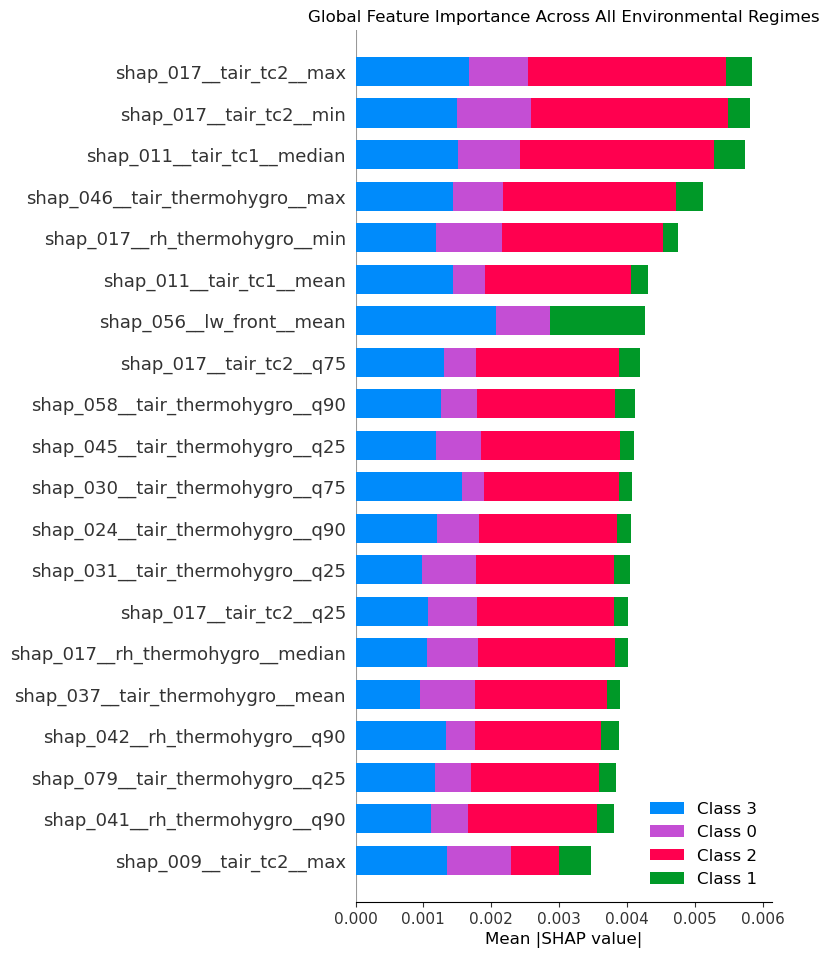

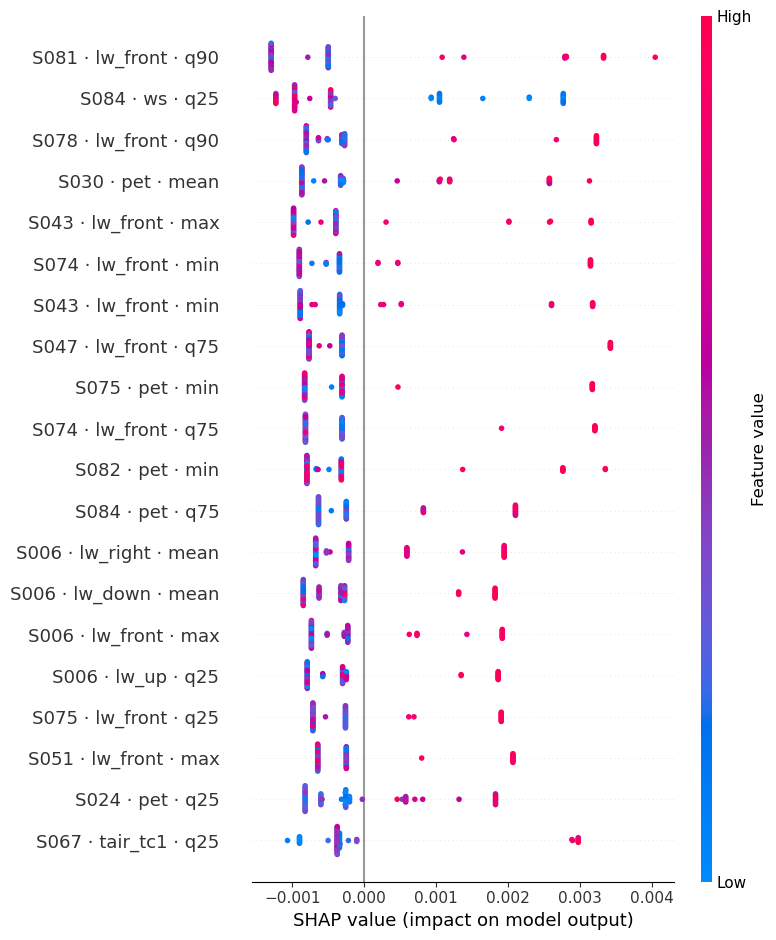

In [67]:
# 1. Slice X exactly how the script does inside _build_rf_and_shap (skipping noise points)
valid_idx = real_y != -1
X_fit = real_X[valid_idx]

# 2. Extract the trained explainer and shap matrix from your script's helper
rf, explainer, shap_abs, shap_signed, _ = _build_rf_and_shap(real_X, real_y)

# 3. Compute raw multi-class shap values
raw_shap_values = explainer.shap_values(X_fit)

# 4. Correctly extract the array for Class/Cluster 0 based on your SHAP version format
if isinstance(raw_shap_values, list):
    # Old SHAP API format: list of arrays
    shap_values_class_0 = raw_shap_values[0]
elif raw_shap_values.ndim == 3:
    # New SHAP API format: (n_samples, n_features, n_classes)
    shap_values_class_0 = raw_shap_values[:, :, 0]
else:
    # Fallback/binary case
    shap_values_class_0 = raw_shap_values

# 5. Run your summary plot cleanly with the appropriate dimensions and custom feature names
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
shap.summary_plot(
    shap_values_class_0, 
    X_fit, 
    feature_names=[_short_name(str(n)) for n in real_feature_names]
)
plt.show()

<Figure size 800x500 with 0 Axes>

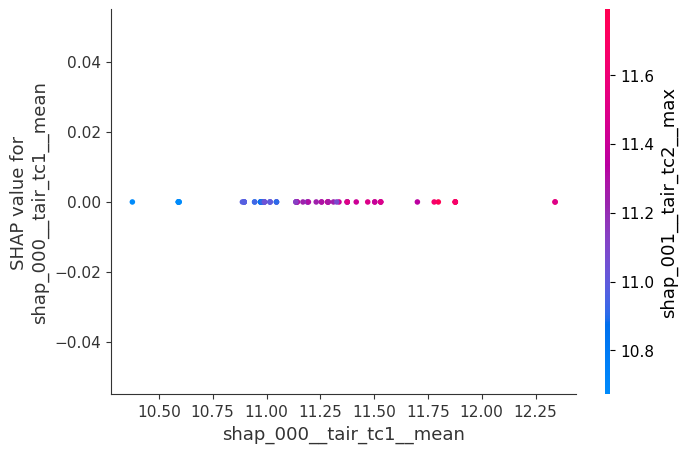

In [68]:
import matplotlib.pyplot as plt
import shap

# 1. Filter out HDBSCAN noise points exactly like the rest of your pipeline
valid_idx = real_y != -1
X_fit = real_X[valid_idx]

# 2. Extract the trained explainer and shap matrix from your pipeline helper
rf, explainer, shap_abs, shap_signed, _ = _build_rf_and_shap(real_X, real_y)

# 3. Compute the raw multi-class SHAP values
raw_shap_values = explainer.shap_values(X_fit)

# 4. Handle the multi-class dimension for Cluster 0 based on your SHAP version format
if isinstance(raw_shap_values, list):
    shap_values_class_0 = raw_shap_values[0]
elif raw_shap_values.ndim == 3:
    shap_values_class_0 = raw_shap_values[:, :, 0]
else:
    shap_values_class_0 = raw_shap_values

# 5. Define your exact feature names as they appear in 'real_feature_names'
# NOTE: Replace these with the actual strings inside your real_feature_names array, 
# for example: "shap_000__tair_tc1__mean" and "shap_001__tair_tc2__max"
target_feature = "shap_000__tair_tc1__mean"      # Replace with your 'Subscription Length' equivalent
interaction_feature = "shap_001__tair_tc2__max" # Replace with your 'Age' equivalent

# 6. Switch matplotlib backend back to interactive (inline) so you can see it 
%matplotlib inline 

# 7. Generate and display the dependence plot
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    ind=target_feature,
    shap_values=shap_values_class_0,
    features=X_fit,
    feature_names=real_feature_names,  # Must be the long raw names matching X_fit columns
    interaction_index=interaction_feature
)
plt.show()

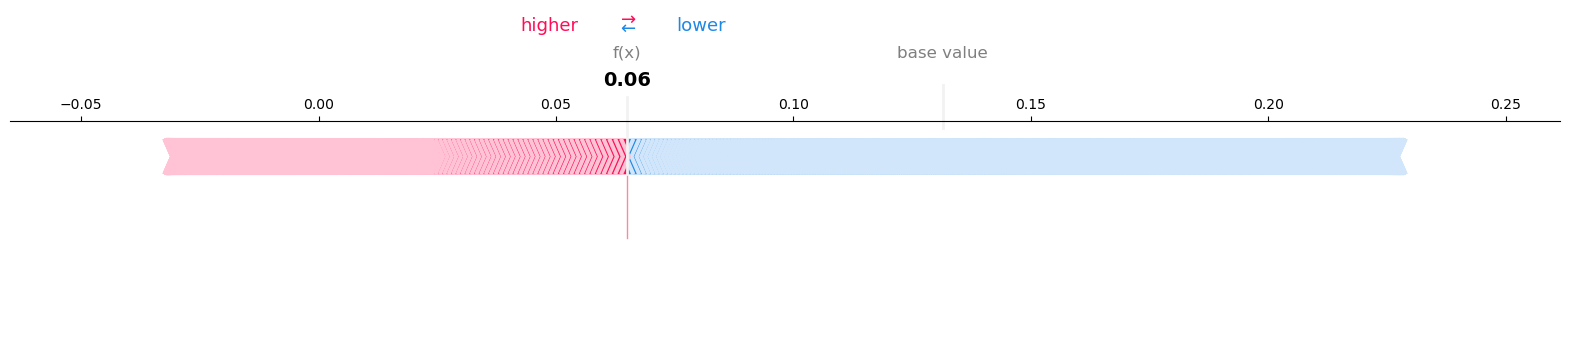

In [69]:
import matplotlib.pyplot as plt
import shap

# 1. Filter out HDBSCAN noise points exactly how your script does
valid_idx = real_y != -1
X_fit = real_X[valid_idx]

# 2. Extract the trained explainer and shap values via your script's helper
rf, explainer, shap_abs, shap_signed, _ = _build_rf_and_shap(real_X, real_y)

# 3. Compute raw multi-class shap values
raw_shap_values = explainer.shap_values(X_fit)

# 4. Handle expected value and SHAP array extraction dynamically by SHAP version
# Targets Cluster 0, Sample Index 0
if isinstance(raw_shap_values, list):
    # Old SHAP API: list of arrays [class_0_array, class_1_array, ...]
    sv_sample = raw_shap_values[0][0, :]
    ev_base = explainer.expected_value[0]
elif raw_shap_values.ndim == 3:
    # New SHAP API: 3D numpy array of shape (n_samples, n_features, n_classes)
    sv_sample = raw_shap_values[0, :, 0]
    ev_base = explainer.expected_value[0]
else:
    # Fallback / standard binary case
    sv_sample = raw_shap_values[0]
    ev_base = explainer.expected_value

# 5. Extract the matching raw data row for sample index 0
# (Since X_fit is a numpy array from your script, we index it with [0, :])
data_sample = X_fit[0, :]

# 6. Build the clean shortened feature names to fit perfectly inside the force plot
short_names = [_short_name(str(n)) for n in real_feature_names]

# 7. Enable interactive plotting backend so the figure renders on screen
%matplotlib inline

# 8. Render the local force plot
# Passing matplotlib=True lets it use regular matplotlib instead of JavaScript HTML rendering
shap.plots.force(
    base_value=ev_base,
    shap_values=sv_sample,
    features=data_sample,
    feature_names=short_names,
    matplotlib=True
)
plt.show()

<Figure size 1200x400 with 0 Axes>

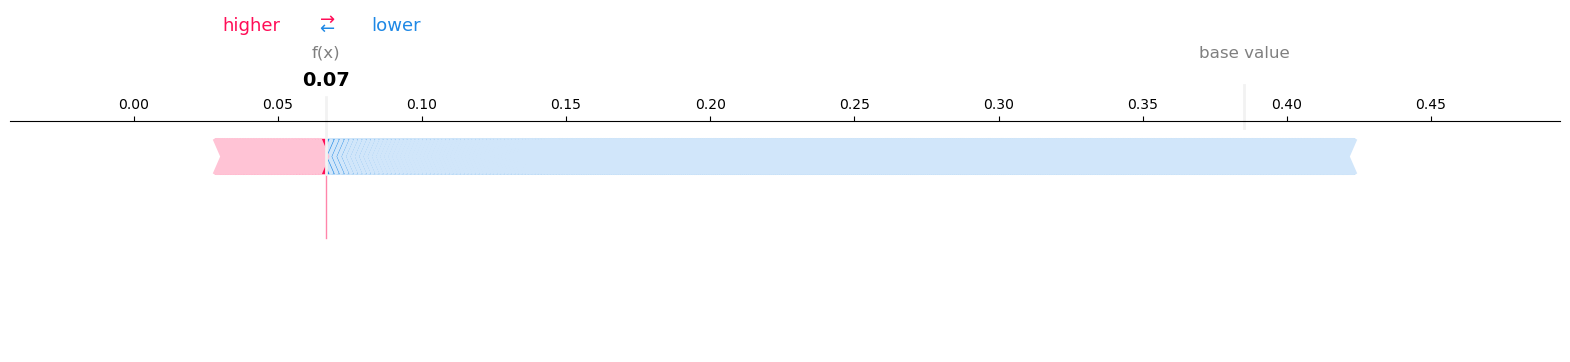

In [70]:
import matplotlib.pyplot as plt
import shap

# 1. Filter out HDBSCAN noise points exactly like the rest of your pipeline
valid_idx = real_y != -1
X_fit = real_X[valid_idx]

# 2. Extract the trained explainer and shap matrix from your script's helper
rf, explainer, shap_abs, shap_signed, _ = _build_rf_and_shap(real_X, real_y)

# 3. Compute raw multi-class shap values
raw_shap_values = explainer.shap_values(X_fit)

# 4. Handle expected value and SHAP array extraction dynamically by SHAP version
# Targets Cluster 1 (index 1), Sample Index 6
if isinstance(raw_shap_values, list):
    # Old SHAP API: list of arrays [class_0_array, class_1_array, ...]
    sv_sample = raw_shap_values[1][6, :]
    ev_base = explainer.expected_value[1]
elif raw_shap_values.ndim == 3:
    # New SHAP API: 3D numpy array of shape (n_samples, n_features, n_classes)
    sv_sample = raw_shap_values[6, :, 1]
    ev_base = explainer.expected_value[1]
else:
    # Fallback / standard binary case
    sv_sample = raw_shap_values[6]
    ev_base = explainer.expected_value

# 5. Extract the matching raw data row for sample index 6
# (X_fit is a numpy array in your script, so we index it with [6, :])
data_sample = X_fit[6, :]

# 6. Build the clean shortened feature names to fit perfectly inside the force plot
short_names = [_short_name(str(n)) for n in real_feature_names]

# 7. Enable interactive plotting backend so the figure renders on screen
%matplotlib inline

# 8. Render the local force plot
# Passing matplotlib=True forces it to render using matplotlib instead of Javascript HTML
plt.figure(figsize=(12, 4))
shap.plots.force(
    base_value=ev_base,
    shap_values=sv_sample,
    features=data_sample,
    feature_names=short_names,
    matplotlib=True
)
plt.show()

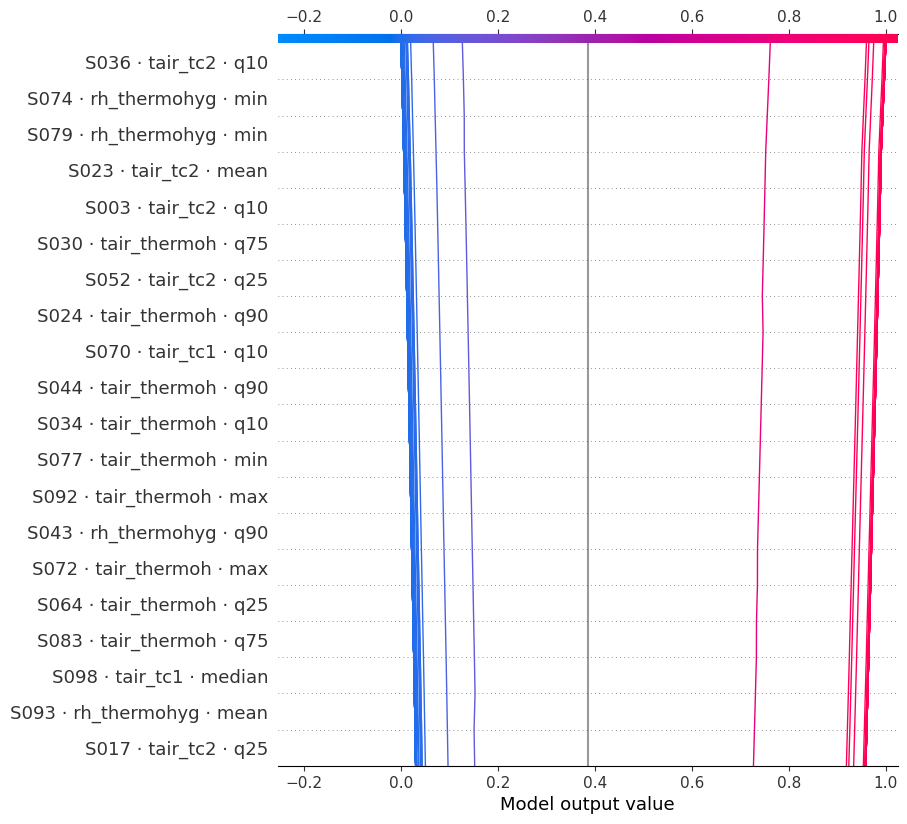

In [71]:
import matplotlib.pyplot as plt
import shap

# 1. Filter out HDBSCAN noise points to match the model training matrix
valid_idx = real_y != -1
X_fit = real_X[valid_idx]

# 2. Extract your trained explainer and multi-class shap values via your script's helper
rf, explainer, shap_abs, shap_signed, _ = _build_rf_and_shap(real_X, real_y)
raw_shap_values = explainer.shap_values(X_fit)

# 3. Safely target Cluster 1 (index 1) based on your SHAP matrix format
if isinstance(raw_shap_values, list):
    # Old SHAP API structure: list of class matrices
    shap_values_class_1 = raw_shap_values[1]
    expected_value_class_1 = explainer.expected_value[1]
elif raw_shap_values.ndim == 3:
    # New SHAP API structure: 3D array of shape (samples, features, classes)
    shap_values_class_1 = raw_shap_values[:, :, 1]
    expected_value_class_1 = explainer.expected_value[1]
else:
    # Fallback structure
    shap_values_class_1 = raw_shap_values
    expected_value_class_1 = explainer.expected_value

# 4. Create shortened feature names using your pipeline's _short_name helper 
# so the chart axis labels stay readable and clear
short_names = [_short_name(str(n)) for n in real_feature_names]

# 5. Enable interactive backend mapping for notebook inline viewing
%matplotlib inline

# 6. Render the global decision plot for Cluster 1
plt.figure(figsize=(10, 6))
shap.decision_plot(
    base_value=expected_value_class_1,
    shap_values=shap_values_class_1,
    features=X_fit,
    feature_names=short_names
)
plt.show()

In [72]:
pca2.components_

array([[ 0.01174204,  0.01174311,  0.0117413 , ...,  0.00095384,
        -0.00091992, -0.00153347],
       [-0.00039775, -0.0004271 , -0.00042168, ...,  0.00707401,
         0.00207226,  0.00345024]], shape=(2, 22000))